# Calculate relative standard errors for different numbers of soil cores

In [12]:
from pprint import pprint
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_DIR = Path.cwd()

In [3]:
def calculate_rse_1(mean, std, n):
    """Within-year RSE [%] from one mean/std pair."""
    # Your original equation:
    # RSE_1 = ((standard deviation / mean) * 100) / number of cores
    if not np.isfinite(mean) or not np.isfinite(std) or mean <= 0:
        return np.nan
    return ((std / mean) * 100) / np.sqrt(n)


def clean_number(value, digits=2):
    """Convert numpy/pandas numbers to rounded Python floats for nicer printing."""
    if pd.isna(value) or not np.isfinite(value):
        return None
    return round(float(value), digits)

In [13]:
def fit_loglog_line(x, y):
    """Fit a straight line in log10-log10 space.

    On log-log axes this is equivalent to y = a * x**b in original units.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if valid.sum() < 2:
        return np.nan, np.nan

    b, log10_a = np.polyfit(np.log10(x[valid]), np.log10(y[valid]), 1)
    return 10 ** log10_a, b


def plot_rse_by_core_number_with_depth_fits(
    rse_by_ncores,
    *,
    depths=None,
    ax=None,
):
    """Log-log RSE plot with one fitted line per depth.

    Input structure:
        {n_cores_per_plot: {depth_cm: rse_percent}}
    """
    if not rse_by_ncores:
        raise ValueError("rse_by_ncores is empty.")

    n_values = np.array(sorted(rse_by_ncores), dtype=float)

    if depths is None:
        depths = sorted({
            depth
            for values_by_depth in rse_by_ncores.values()
            for depth in values_by_depth
        })

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    else:
        fig = ax.figure

    cmap = plt.get_cmap("viridis", len(depths))
    n_grid = np.logspace(np.log10(n_values.min()), np.log10(n_values.max()), 200)

    fit_rows = []

    for i, depth in enumerate(depths):
        color = cmap(i)
        rse_values = np.array([
            rse_by_ncores.get(int(n), {}).get(depth, np.nan)
            for n in n_values
        ], dtype=float)

        valid = np.isfinite(rse_values) & (rse_values > 0)
        if valid.sum() == 0:
            continue

        # Points: legend entry for depth only.
        ax.scatter(
            n_values[valid],
            rse_values[valid],
            s=45,
            color=color,
            alpha=0.9,
            label=f"{depth} cm",
        )

        # Depth-specific fit: same color, no legend entry.
        a, b = fit_loglog_line(n_values[valid], rse_values[valid])
        fit_rows.append({
            "depth_cm": depth,
            "a": a,
            "b": b,
            "equation": f"RSE = {a:.2f} * n^{b:.2f}" if np.isfinite(a) and np.isfinite(b) else None,
        })

        if np.isfinite(a) and np.isfinite(b):
            ax.plot(
                n_grid,
                a * n_grid ** b,
                color=color,
                lw=2,
                alpha=0.85,
                label="_nolegend_",
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of soil cores per plot")
    ax.set_ylabel("Relative standard error [%]")

    ax.set_xticks(n_values)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

    ax.legend(title="Depth", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

    return fig, ax, pd.DataFrame(fit_rows)

## 2 cores per plot

In [6]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
    "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
    "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
}
n_cores = 2

rows = []
rse_1_by_year_and_depth = {}

for label, file in simulated_data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"]/2)
        mean = row["simulated_mean"]
        std = row["simulated_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)


RSE results [%] using n_cores=2:
{'rse_1_by_year_and_depth': {1995: {7: 23.15,
                                    15: 16.22,
                                    22: 28.38,
                                    30: 27.9,
                                    37: 25.77,
                                    45: 29.58,
                                    52: 48.7,
                                    60: 99.22},
                             1996: {7: 23.29,
                                    15: 17.11,
                                    22: 32.52,
                                    30: 35.59,
                                    37: 43.61,
                                    45: 47.26,
                                    52: 62.84,
                                    60: 154.31},
                             1997: {7: 29.17,
                                    15: 21.82,
                                    22: 26.41,
                                    30: 17.85,
                             

## 3 cores per plot

In [7]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_3_layer_15.csv",
    "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_3_layer_15.csv",
    "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_3_layer_15.csv",
}
n_cores = 3

rows = []
rse_1_by_year_and_depth = {}

for label, file in simulated_data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"])
        mean = row["simulated_mean"]
        std = row["simulated_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)

RSE results [%] using n_cores=3:
{'rse_1_by_year_and_depth': {1995: {7: 17.29,
                                    22: 11.49,
                                    37: 18.09,
                                    52: 12.13,
                                    67: 17.38,
                                    82: 24.72,
                                    97: 29.88,
                                    112: 78.21},
                             1996: {7: 16.18,
                                    22: 14.28,
                                    37: 20.45,
                                    52: 17.15,
                                    67: 24.12,
                                    82: 32.55,
                                    97: 39.65,
                                    112: 94.1},
                             1997: {7: 16.86,
                                    22: 15.97,
                                    37: 20.8,
                                    52: 20.68,
                            

## 5 cores per plot

In [8]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_5_layer_15.csv",
    "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_5_layer_15.csv",
    "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_5_layer_15.csv",
}
n_cores = 5

rows = []
rse_1_by_year_and_depth = {}

for label, file in simulated_data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"])
        mean = row["simulated_mean"]
        std = row["simulated_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)


RSE results [%] using n_cores=5:
{'rse_1_by_year_and_depth': {1995: {7: 14.71,
                                    22: 11.89,
                                    37: 19.24,
                                    52: 16.59,
                                    67: 17.4,
                                    82: 25.46,
                                    97: 27.22,
                                    112: 59.62},
                             1996: {7: 12.5,
                                    22: 10.52,
                                    37: 19.97,
                                    52: 23.15,
                                    67: 22.24,
                                    82: 25.8,
                                    97: 44.2,
                                    112: 94.84},
                             1997: {7: 13.93,
                                    22: 11.52,
                                    37: 21.09,
                                    52: 16.85,
                              

## 10 cores per plot

In [9]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_10_layer_15.csv",
    "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_10_layer_15.csv",
    "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_10_layer_15.csv",
}
n_cores = 10

rows = []
rse_1_by_year_and_depth = {}

for label, file in simulated_data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"])
        mean = row["simulated_mean"]
        std = row["simulated_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)


RSE results [%] using n_cores=10:
{'rse_1_by_year_and_depth': {1995: {7: 11.34,
                                    22: 8.86,
                                    37: 15.17,
                                    52: 15.34,
                                    67: 16.44,
                                    82: 18.22,
                                    97: 18.02,
                                    112: 45.83},
                             1996: {7: 8.93,
                                    22: 7.46,
                                    37: 13.77,
                                    52: 14.44,
                                    67: 15.98,
                                    82: 18.85,
                                    97: 27.44,
                                    112: 88.97},
                             1997: {7: 10.2,
                                    22: 7.86,
                                    37: 14.5,
                                    52: 16.18,
                               

## 100 cores per plot

In [10]:
simulated_data = {
    "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_100_layer_15.csv",
    "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_100_layer_15.csv",
    "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_100_layer_15.csv",
}
n_cores = 300

rows = []
rse_1_by_year_and_depth = {}

for label, file in simulated_data.items():
    df = pd.read_csv(file)
    df = df[df["system"] == "soil_core"].copy()
    df = df.sort_values("depth")

    year = int(df["year"].dropna().iloc[0])
    rse_1_by_year_and_depth[year] = {}

    for _, row in df.iterrows():
        depth = int(row["depth"])
        mean = row["simulated_mean"]
        std = row["simulated_std"]
        rse_1 = calculate_rse_1(mean, std, n_cores)

        rse_1_by_year_and_depth[year][depth] = clean_number(rse_1)
        rows.append({
            "year": year,
            "depth": depth,
            "mean": mean,
            "std": std,
            "rse_1": rse_1,
        })

rse_results = {
    "rse_1_by_year_and_depth": rse_1_by_year_and_depth
}

print(f"RSE results [%] using n_cores={n_cores}:")
pprint(rse_results, sort_dicts=True)


RSE results [%] using n_cores=300:
{'rse_1_by_year_and_depth': {1995: {7: 2.04,
                                    22: 1.61,
                                    37: 2.81,
                                    52: 2.79,
                                    67: 2.88,
                                    82: 3.16,
                                    97: 4.09,
                                    112: 7.37},
                             1996: {7: 1.68,
                                    22: 1.27,
                                    37: 2.76,
                                    52: 3.16,
                                    67: 3.26,
                                    82: 3.9,
                                    97: 6.12,
                                    112: 19.81},
                             1997: {7: 1.82,
                                    22: 1.34,
                                    37: 2.53,
                                    52: 2.51,
                                    67: 2.57

# Plot relative standard error against core number for the 1996 values

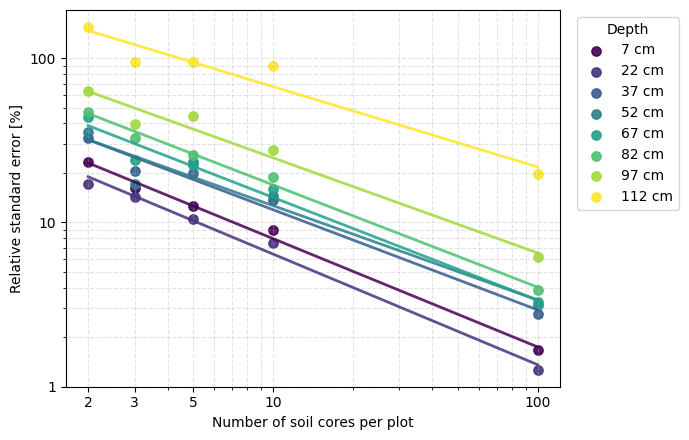

In [16]:
rse_1996_by_ncores = {
    2: {7: 23.29, 22: 17.11, 37: 32.52, 52: 35.59, 67: 43.61, 82: 47.26, 97: 62.84, 112: 154.31},
    3: {7: 16.18, 22: 14.28, 37: 20.45, 52: 17.15, 67: 24.12, 82: 32.55, 97: 39.65, 112: 94.10},
    5: {7: 12.50, 22: 10.52, 37: 19.97, 52: 23.15, 67: 22.24, 82: 25.80, 97: 44.20, 112: 94.84},
    10: {7: 8.93, 22: 7.46, 37: 13.77, 52: 14.44, 67: 15.98, 82: 18.85, 97: 27.44, 112: 88.97},
    100: {7: 1.68, 22: 1.27, 37: 2.76, 52: 3.16, 67: 3.26, 82: 3.9, 97: 6.12, 112: 19.81}
}

fig, ax, rse_fit_parameters_1996 = plot_rse_by_core_number_with_depth_fits(
    rse_1996_by_ncores,
)
#rse_fit_parameters_1996 # prints parameters of fitted curves

